<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/04-Pandas/02_Olympics_History_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Reading & cleaning Data

In [2]:
bio_D=pd.read_csv('/content/drive/MyDrive/bios.csv')
bio_D.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [3]:
result_D=pd.read_parquet('/content/drive/MyDrive/results.parquet')
result_D.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,17.0,True,None
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,None
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,32.0,True,None
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,None
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,None


In [71]:
t_d=bio_D.merge(result_D,how='outer')
t_d.sample(4)

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,year,type,discipline,event,as,noc,team,place,tied,medal
197711,92548,Guillaume Jeannet,1977-10-17,Mâcon,Saône-et-Loire,FRA,France,187.0,85.0,NaN,2000.0,Summer,Rowing,"Quadruple Sculls, Men (Olympic)",Guillaume Jeannet,FRA,France,10.0,False,None
266197,124237,Mohammed Aman,1994-01-10,Asella,Oromiya,ETH,Ethiopia,165.0,58.0,NaN,2010.0,Summer,Athletics,"1,000 metres, Boys (YOG)",Mohammed Aman,ETH,None,1.0,False,Gold
234719,108770,Wu Yanan,1981-09-14,Zhangjiangang,Hebei,CHN,People's Republic of China,170.0,64.0,NaN,2008.0,Summer,Handball,"Handball, Women (Olympic)",Wu Yanan,CHN,People's Republic of China,6.0,False,None
28410,15628,Filiberto Mercado,1938-06-28,Pachuca,Hidalgo,MEX,Mexico,162.0,60.0,NaN,1960.0,Summer,Cycling Road (Cycling),"100 kilometres Team Time Trial, Men (Olympic)",Filiberto Mercado,MEX,Mexico,24.0,False,None


In [5]:
t_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308646 entries, 0 to 308645
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   athlete_id    308646 non-null  int64  
 1   name          308646 non-null  object 
 2   born_date     305928 non-null  object 
 3   born_city     247091 non-null  object 
 4   born_region   247091 non-null  object 
 5   born_country  247091 non-null  object 
 6   NOC           308645 non-null  object 
 7   height_cm     236927 non-null  float64
 8   weight_kg     227305 non-null  float64
 9   died_date     73526 non-null   object 
 10  year          305807 non-null  float64
 11  type          305807 non-null  object 
 12  discipline    308407 non-null  object 
 13  event         308408 non-null  object 
 14  as            308408 non-null  object 
 15  noc           308407 non-null  object 
 16  team          121714 non-null  object 
 17  place         283193 non-null  float64
 18  tied

In [6]:
t_d.describe()

,athlete_id,height_cm,weight_kg,year,place
count,308646.000000,236927.000000,227305.000000,305807.000000,283193.000000
mean,72682.064164,175.350306,70.555223,1982.239223,16.102764
std,41324.080740,10.450772,14.163493,30.983982,19.322611
min,1.000000,127.000000,25.000000,1896.000000,1.000000
25%,34456.250000,168.000000,60.000000,1964.000000,5.000000
50%,73796.500000,175.000000,70.000000,1992.000000,9.000000
75%,107196.000000,183.000000,79.000000,2008.000000,20.000000
max,149814.000000,226.000000,198.000000,2022.000000,185.000000


### Country Ranking on Medal

In [72]:
medal_table = t_d.groupby(['NOC', 'medal']).size().unstack(fill_value=0)
medal_table = medal_table[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False)
#This count each gold a person win even if they are in a team

In [73]:
gold_medal=t_d[t_d['medal']=='Gold']
gold_medal.groupby(gold_medal['NOC'])['medal'].count().sort_values(ascending=False)
#This count each gold a person win even if they are in a team

,medal
NOC,
United States,2709
Soviet Union,952
Great Britain,713
Germany,704
Italy,604
...,...
Suriname,1
Soviet Union Sweden Unified Team,1
Tajikistan,1


In [9]:
rmeadal_table=t_d[t_d['medal'].isin(['Gold','Silver','Bronze'])].drop_duplicates(subset=['year','event','NOC'])

medal_table=rmeadal_table.groupby(['NOC','medal']).size().unstack(fill_value=0)

medal_table=medal_table[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False)

medal_table.head(10)

medal,Gold,Silver,Bronze
NOC,,,
United States,901,692,626
Soviet Union,346,267,255
Germany,264,307,291
Great Britain,261,296,291
People's Republic of China,256,194,162
Italy,246,224,260
France,244,264,320
Sweden,185,197,228
Japan,184,171,185


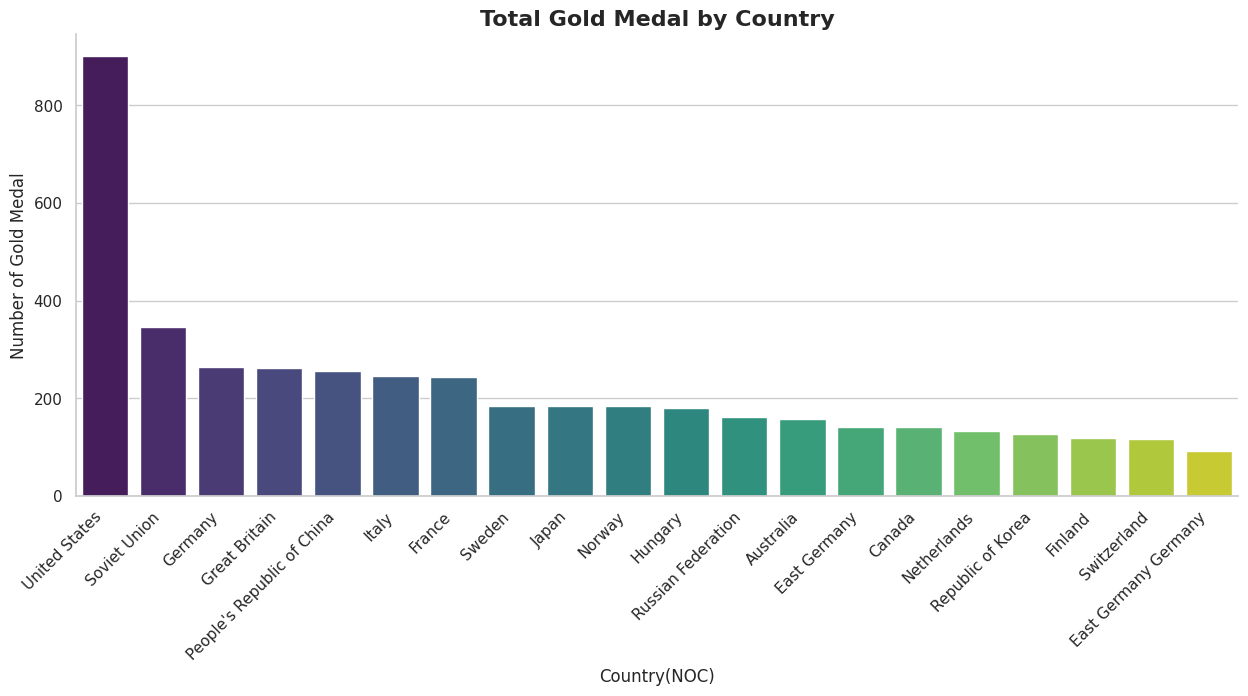

In [10]:
top_20=medal_table.head(20)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(15,6))


plt.title("Total Gold Medal by Country",fontsize=16, fontweight='bold')

sns.barplot(
            x=top_20.index,
            y=top_20['Gold'],
            hue=top_20.index,
            palette="viridis",
            legend=False
           )

plt.xticks(rotation=45,ha='right')#ha aligns the text better


plt.ylabel("Number of Gold Medal",fontsize=12)
plt.xlabel("Country(NOC)",fontsize=12)

sns.despine()

plt.show()

### Unique Participant from different region of INDIA

In [11]:
t_d.query('born_country=="IND" and born_region=="Uttar Pradesh" ')
it_d=t_d.query('NOC=="India" and born_country=="IND"')
unique_par=it_d.drop_duplicates(subset=['athlete_id'])

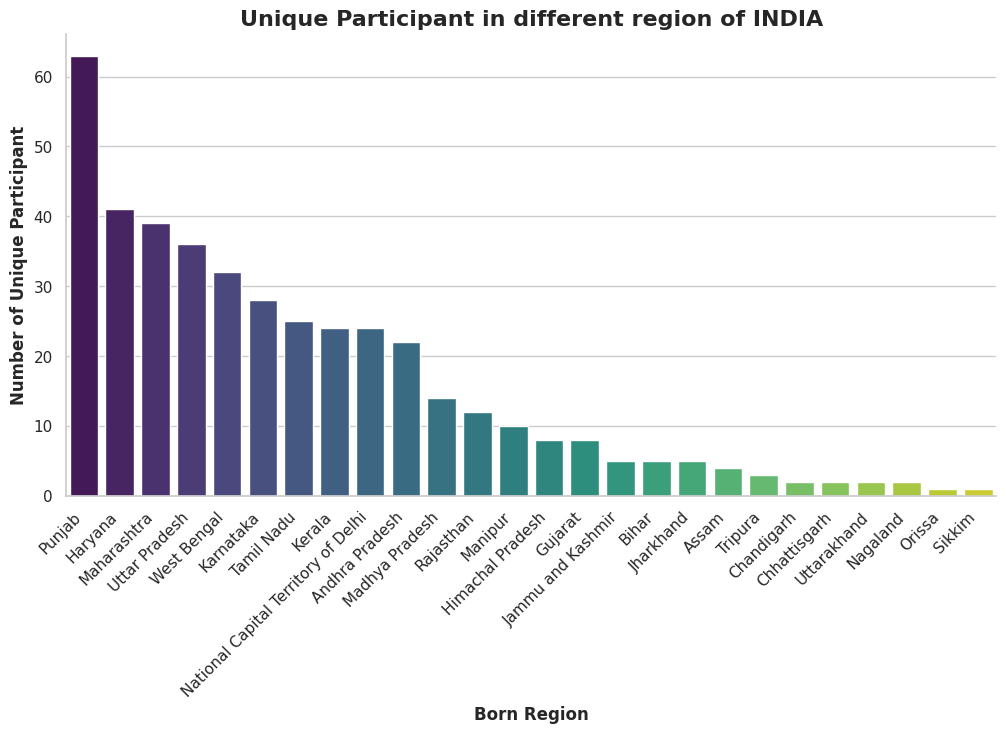

In [12]:
participant_d=unique_par.groupby(['born_region'])['name'].count().sort_values(ascending=False).reset_index()

#Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))

sns.barplot(
            x=participant_d['born_region'] ,
            y=participant_d['name'] ,
            hue=participant_d['born_region'],
            palette="viridis" ,
            legend=False
           )

plt.title("Unique Participant in different region of INDIA",fontsize=16,fontweight="bold")
plt.xlabel("Born Region",fontsize=12,fontweight="bold")
plt.ylabel("Number of Unique Participant",fontsize=12,fontweight="bold")

plt.xticks(rotation=45,ha="right")
sns.despine()

plt.show()


### Women Unique Participant

In [13]:
p_t_d=t_d[t_d['event'].str.contains('Women',na=False)]

u_p_d=p_t_d.drop_duplicates(subset=['athlete_id'])

unique_W_par=u_p_d.groupby(['year'])['name'].count().reset_index()

unique_W_par.head(10)

,year,name
0,1900.0,16
1,1904.0,6
2,1908.0,41
3,1912.0,52
4,1920.0,69
5,1924.0,115
6,1928.0,259
7,1932.0,109
8,1936.0,338
9,1948.0,442


##### Visuals

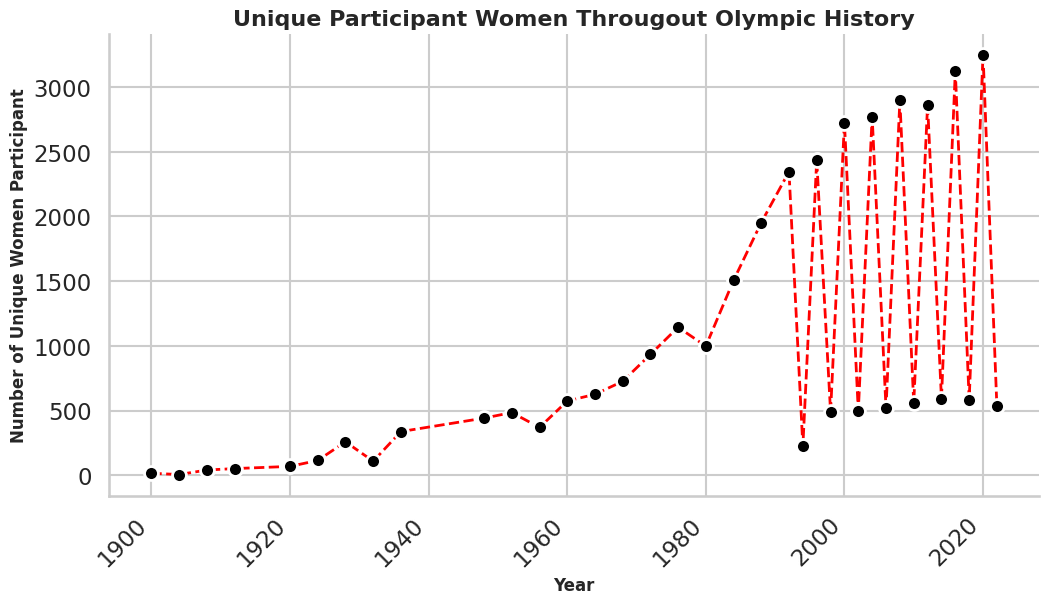

In [14]:
#Visualization
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid",context="talk")
plt.title("Unique Participant Women Througout Olympic History",fontsize=16,fontweight="bold")

sns.lineplot(
          x=unique_W_par['year'],
          y=unique_W_par['name'],
          marker='o',
          markersize=10,
          markeredgecolor='white',
          markerfacecolor='black',
          markeredgewidth=2,
          color='red',
          linestyle='--',
          linewidth=2
        )

plt.xlabel("Year",fontsize=12,fontweight="bold")
plt.ylabel("Number of Unique Women Participant",fontsize=12,fontweight="bold")

plt.xticks(rotation=45,ha="right")
sns.despine()

plt.show()


In [15]:
#The dips in graphs shows the women participant in winter olympics
#by this Graph we can see that the Women Participants increase masively in b/w 1980 to 2000
#the same pataren might not be shown in different country specific Women participant
#as in different country the timeline of women fighting for there right changes
#we will be looking at diffent country ex-USA , RUS , CHN ,IND and etc later on

### Comparison of Participant

In [16]:
pm_t_d=t_d[t_d['event'].str.contains('Men',na=False)]

u_pm_d=pm_t_d.drop_duplicates(subset=['athlete_id'])

unique_M_par=u_pm_d.groupby(['year'])['name'].count().reset_index()

##### Visuals

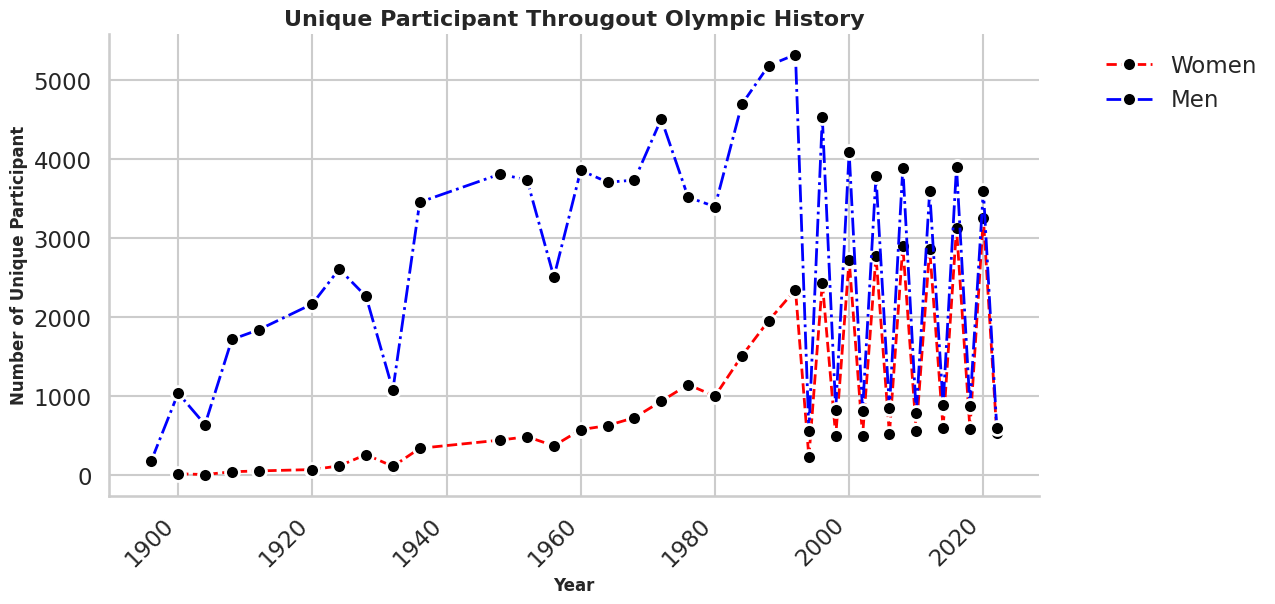

In [17]:
from re import L
#Visualization
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid",context="talk")
plt.title("Unique Participant Througout Olympic History",fontsize=16,fontweight="bold")

#For Women

sns.lineplot(
              x=unique_W_par['year'],
              y=unique_W_par['name'],
              marker='o',
              markersize=10,
              markeredgecolor='white',
              markerfacecolor='black',
              markeredgewidth=2,
              color='red',
              linestyle='--',
              linewidth=2,
              label='Women'
            )

#For Men

sns.lineplot(
              x=unique_M_par['year'],
              y=unique_M_par['name'],
              marker='o',
              markersize=10,
              markeredgecolor='white',
              markerfacecolor='black',
              markeredgewidth=2,
              color='blue',
              linestyle='-.',
              linewidth=2,
              label='Men'
            )

plt.xlabel("Year",fontsize=12,fontweight="bold")
plt.ylabel("Number of Unique Participant",fontsize=12,fontweight="bold")

plt.xticks(rotation=45,ha="right")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

sns.despine()

plt.show()

## Physical Atribute Analysis

In [35]:
cp_t_d=t_d.dropna(subset=['height_cm','weight_kg'])
ucp_t_d=cp_t_d.drop_duplicates(subset=['athlete_id'])

#For Men
mucp_t_d=ucp_t_d[ucp_t_d['event'].str.contains('Men',na=False)]
gmucp_t_d=mucp_t_d.groupby(['discipline']).agg({'height_cm':'mean','weight_kg':'mean'}).reset_index()

# sport='Swimming|Gymnastics|Basketball|Soccer|Football|Ice Hockey|Skiing|Boxing|Athletics|Diving|Table|Cycling|Badminton|Rowing'
# sp_gmucp_t_d=gmucp_t_d[gmucp_t_d['discipline'].str.contains(sport,case=False,na=False)]
sp_gmucp_t_d=gmucp_t_d[gmucp_t_d['discipline'].isin(['Alpine Skiing (Skiing)','Artistic Gymnastics (Gymnastics)','Basketball (Basketball)',
                                                     'Football (Football)','Ice Hockey (Ice Hockey)','Swimming (Aquatics)','Table Tennis',
                                                     'Cycling Road (Cycling)','Badminton','Rowing'])]

#For Women
wucp_t_d=ucp_t_d[ucp_t_d['event'].str.contains('Women',na=False)]
gwucp_t_d=wucp_t_d.groupby(['discipline']).agg({'height_cm':'mean','weight_kg':'mean'}).reset_index()

sp_gwucp_t_d=gwucp_t_d[gwucp_t_d['discipline'].isin(['Alpine Skiing (Skiing)','Artistic Gymnastics (Gymnastics)','Basketball (Basketball)',
                                                     'Football (Football)','Ice Hockey (Ice Hockey)','Swimming (Aquatics)','Table Tennis',
                                                     'Cycling Road (Cycling)','Badminton','Rowing'])]

sp_gwucp_t_d

,discipline,height_cm,weight_kg
1,Alpine Skiing (Skiing),166.837689,61.888583
3,Artistic Gymnastics (Gymnastics),155.831272,47.294170
6,Badminton,168.020134,61.127517
7,Basketball (Basketball),182.084081,73.313901
18,Cycling Road (Cycling),167.590361,57.292169
23,Football (Football),167.409589,60.779452
28,Ice Hockey (Ice Hockey),167.590909,64.610390
35,Rowing,176.246844,69.542777
47,Swimming (Aquatics),170.538571,60.737857
48,Table Tennis,164.965079,57.787302


##### Visuals

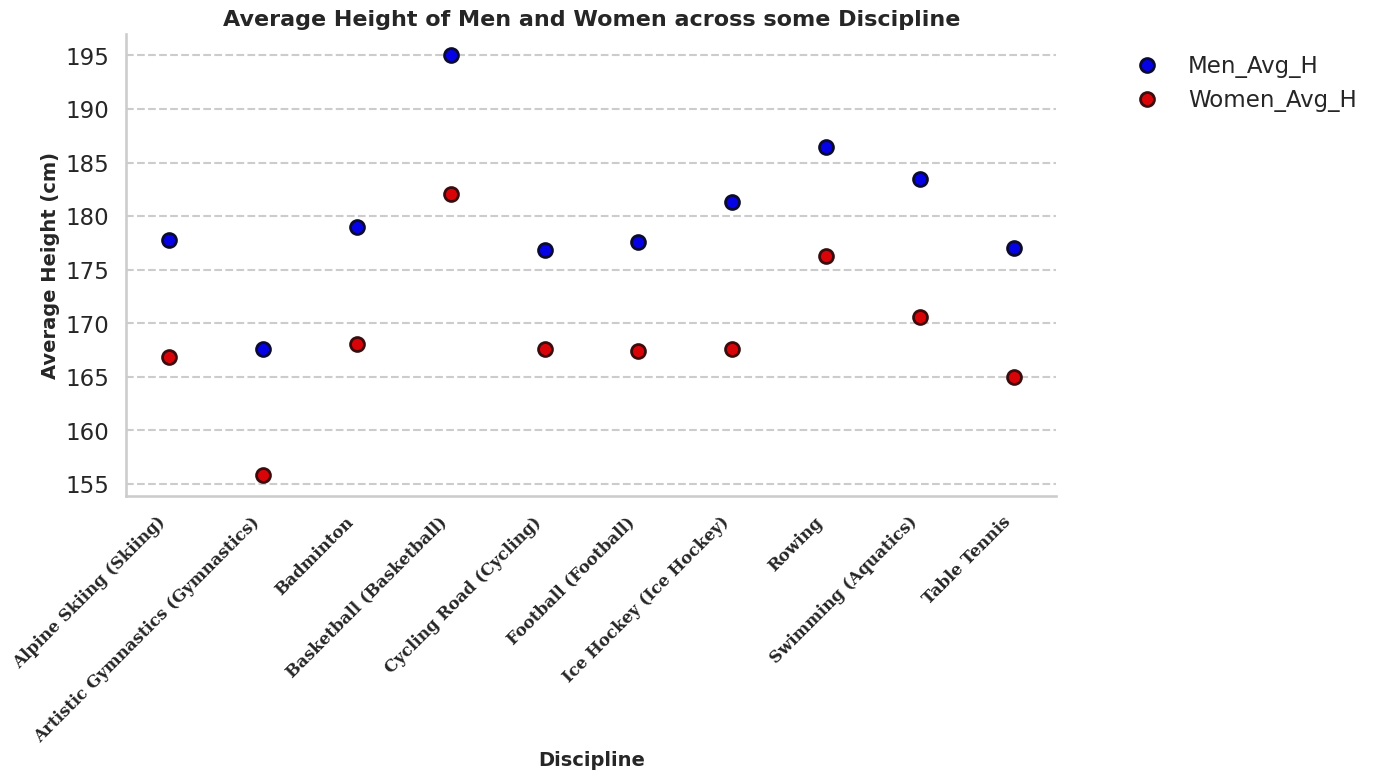

In [80]:

plt.figure(figsize=(12,6))

sns.set_theme(style="whitegrid",context="talk")
plt.title("Average Height of Men and Women across some Discipline",fontsize=16,fontweight="bold")

#Men Avg Height
sns.lineplot(
              x=sp_gmucp_t_d['discipline'],
              y=sp_gmucp_t_d['height_cm'],
              marker='o',
              markersize=10,
              markeredgecolor='#0b0a30',
              markerfacecolor='#0602e6',
              markeredgewidth=2,
              linestyle=' ',
              label='Men_Avg_H')
#Women Avg Height
sns.lineplot(
              x=sp_gwucp_t_d['discipline'],
              y=sp_gwucp_t_d['height_cm'],
              marker='o',
              markersize=10,
              markeredgecolor='#3b0c0d',
              markerfacecolor='#d90408',
              markeredgewidth=2,
              linestyle=' ',
              label='Women_Avg_H')

plt.xlabel("Discipline",fontsize=14,fontweight="bold")
plt.ylabel("Average Height (cm)",fontsize=14,fontweight="bold")

plt.xticks(rotation=45,ha="right",fontsize=12,
           fontweight='bold',
           fontfamily='serif')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

sns.despine()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.show()

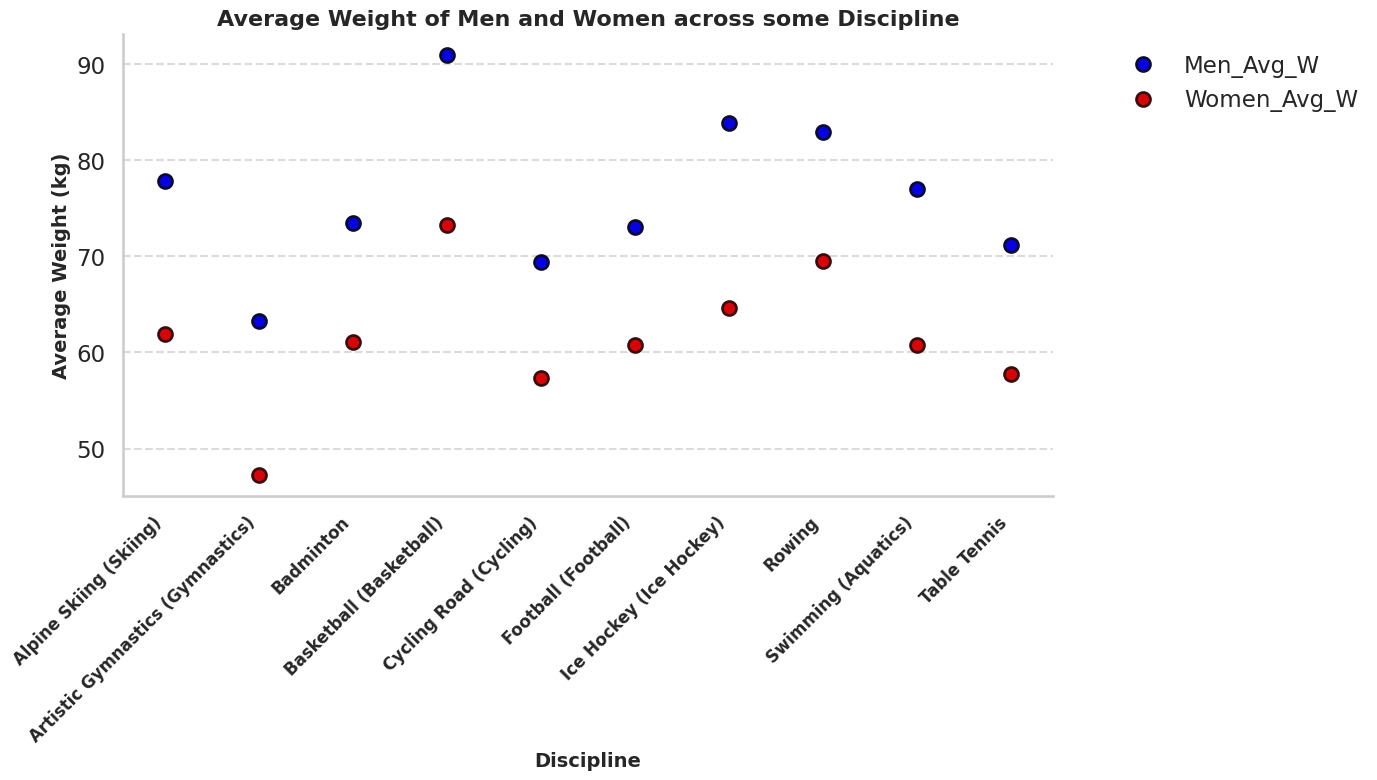

In [84]:

plt.figure(figsize=(12,6))

sns.set_theme(style="whitegrid",context="talk")
plt.title("Average Weight of Men and Women across some Discipline",fontsize=16,fontweight="bold")

#Men Avg Weight
sns.lineplot(
              x=sp_gmucp_t_d['discipline'],
              y=sp_gmucp_t_d['weight_kg'],
              marker='o',
              markersize=10,
              markeredgecolor='#0b0a30',
              markerfacecolor='#0602e6',
              markeredgewidth=2,
              linestyle=' ',
              label='Men_Avg_W')
#Women Avg Weight
sns.lineplot(
              x=sp_gwucp_t_d['discipline'],
              y=sp_gwucp_t_d['weight_kg'],
              marker='o',
              markersize=10,
              markeredgecolor='#3b0c0d',
              markerfacecolor='#d90408',
              markeredgewidth=2,
              linestyle=' ',
              label='Women_Avg_W')

plt.xlabel("Discipline",fontsize=14,fontweight="bold")
plt.ylabel("Average Weight (kg)",fontsize=14,fontweight="bold")

plt.xticks(rotation=45,ha="right",fontsize=12,
           fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

sns.despine()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.show()